<a href="https://colab.research.google.com/github/kwamelevi07-cyber/DI_BOOTCAMP/blob/main/Copie_de_Bienvenue_dans_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

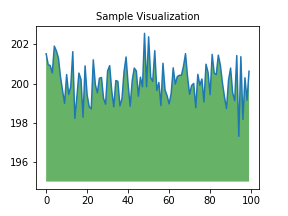

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

### 1. Prétraitement des données
Nous chargeons les 10 000 mots les plus fréquents et transformons les listes d'entiers en vecteurs binaires.

In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 783.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 111.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [ ]:
import numpy as np
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1.1 Charger le jeu de données
num_words = 10_000
(train_data, train_labels), (test_data, test_labels) = keras.datasets.imdb.load_data(num_words=num_words)

# 1.2 Vectorisation des séquences
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# 1.3 Création d'un ensemble de validation
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

print(f"Données d'entraînement : {partial_x_train.shape}")
print(f"Données de validation : {x_val.shape}")

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Données d'entraînement : (15000, 10000)
Données de validation : (10000, 10000)


### 2. Construction du modèle
Nous créons une pile de couches `Dense` avec activation ReLU et une sortie Sigmoïde.

In [ ]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

### 3. Entraînement
Nous entraînons le modèle pendant 20 époques pour observer le comportement de l'apprentissage.

In [ ]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.7791 - loss: 0.5098 - val_accuracy: 0.8313 - val_loss: 0.4124
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8968 - loss: 0.3067 - val_accuracy: 0.8875 - val_loss: 0.3019
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9202 - loss: 0.2321 - val_accuracy: 0.8787 - val_loss: 0.3001
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9379 - loss: 0.1853 - val_accuracy: 0.8903 - val_loss: 0.2741
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9477 - loss: 0.1556 - val_accuracy: 0.8875 - val_loss: 0.2867
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9564 - loss: 0.1320 - val_accuracy: 0.8869 - val_loss: 0.2872
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9638 - loss: 0.1122 - val_accuracy: 0.8831 - val_loss: 0.3161
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9708 - loss: 0.0960 - val_accuracy: 0.8722 - v

### 4. Analyse des résultats
Visualisons la perte et la précision pour détecter le surapprentissage (overfitting).

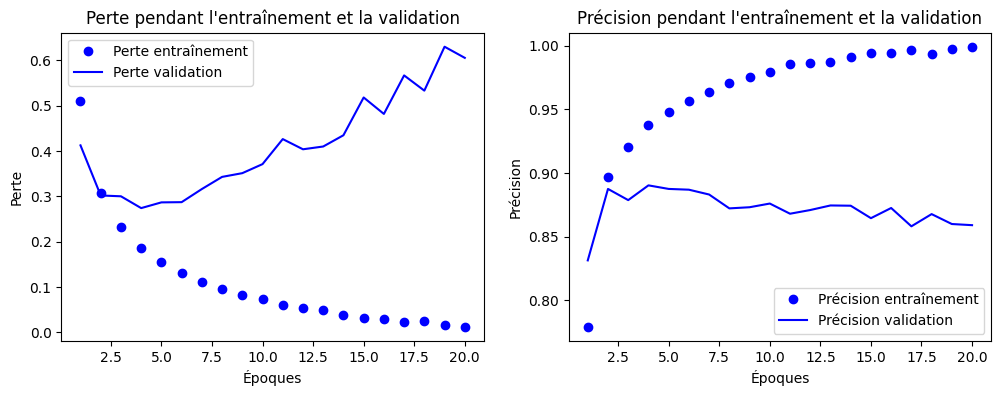

In [ ]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']

epochs = range(1, len(loss_values) + 1)

plt.figure(figsize=(12, 4))

# Graphique de la perte
plt.subplot(1, 2, 1)
plt.plot(epochs, loss_values, 'bo', label='Perte entraînement')
plt.plot(epochs, val_loss_values, 'b', label='Perte validation')
plt.title('Perte pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Perte')
plt.legend()

# Graphique de la précision
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, 'bo', label='Précision entraînement')
plt.plot(epochs, val_acc, 'b', label='Précision validation')
plt.title('Précision pendant l\'entraînement et la validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()

plt.show()

### 5. Modèle final et évaluation
D'après les graphiques, le surapprentissage commence généralement vers la 4ème époque. Réentraînons un modèle propre et évaluons-le sur le test set.

In [ ]:
# Modèle final avec le nombre d'époques optimal (4)
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.fit(x_train, y_train, epochs=4, batch_size=512)

results = model.evaluate(x_test, y_test)
print(f"\nPerte sur le test set : {results[0]:.4f}")
print(f"Précision sur le test set : {results[1]:.4f}")

Epoch 1/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8072 - loss: 0.4701
Epoch 2/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9017 - loss: 0.2737
Epoch 3/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9247 - loss: 0.2119
Epoch 4/4
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9336 - loss: 0.1825
782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 868us/step - accuracy: 0.8844 - loss: 0.2902

Perte sur le test set : 0.2902
Précision sur le test set : 0.8844
